<a href="https://colab.research.google.com/github/LoesterBotelho/SCTEC/blob/main/SCTEC_Desafio_Loester1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3702/2214087861.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpo, x='hotel', palette='viridis')
/tmp/ipykernel_3702/2214087861.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpo, x='is_canceled', y='lead_time', palette='Set2')


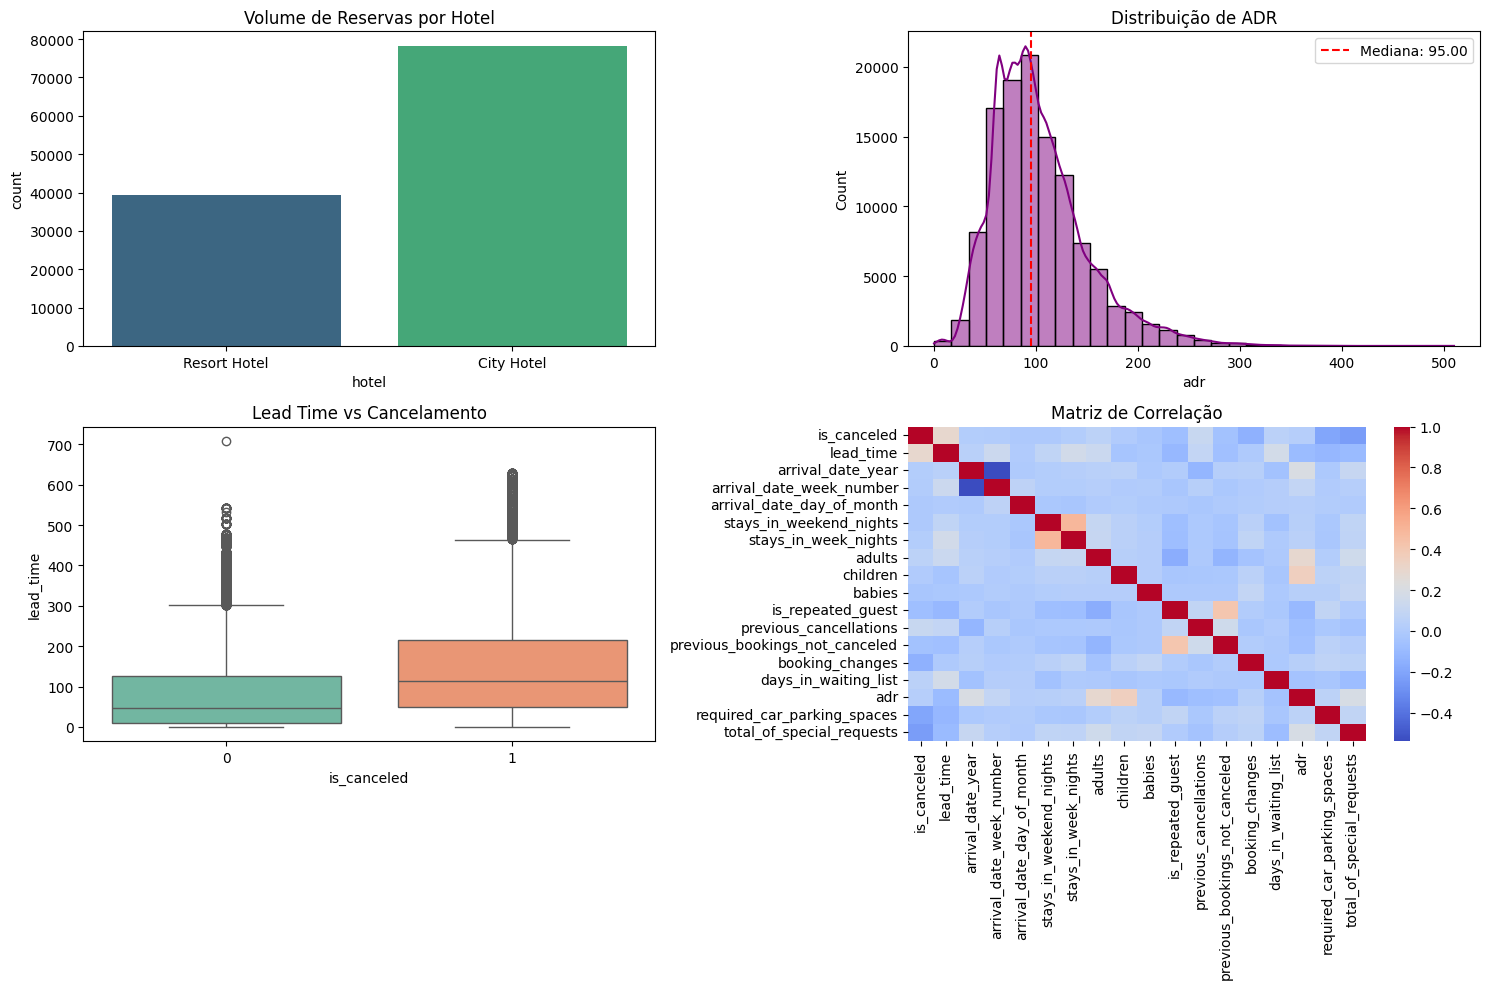

Acurácia Final: 82.47%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87     14656
           1       0.81      0.69      0.75      8830

    accuracy                           0.82     23486
   macro avg       0.82      0.80      0.81     23486
weighted avg       0.82      0.82      0.82     23486



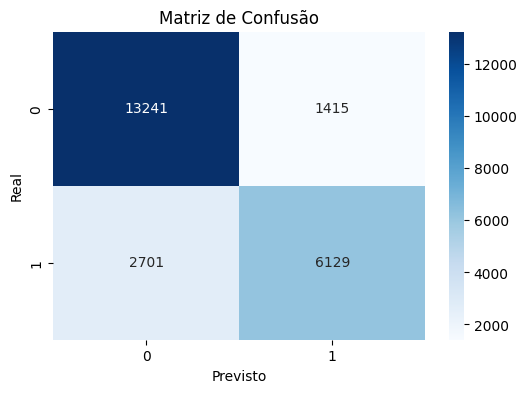

In [14]:
# -*- coding: utf-8 -*-
"""
Projeto: Análise e Predição de Reservas Hoteleiras
Autor: Loester Franco Botelho
Matrícula: 2664322
Curso: Carreira Tech - Trilha Inteligência Artificial
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. CARREGAMENTO DOS DADOS [1]
df = pd.read_csv("hotel_bookings.csv")

# 2. TRATAMENTO E LIMPEZA [1, 2]
# Removendo colunas com excesso de nulos e preenchendo valores faltantes [3, 4]
df_limpo = df.drop(columns=['agent', 'company'])
df_limpo['children'] = df_limpo['children'].fillna(0)
df_limpo['country'] = df_limpo['country'].fillna('Unknown')

# Tratamento de Outliers: Foco em ADR realístico e Lead Time inferior a 2 anos [4, 5]
df_limpo = df_limpo[(df_limpo['adr'] > 0) & (df_limpo['adr'] < 1000)]
df_limpo = df_limpo[df_limpo['lead_time'] < 730]

# 3. ANÁLISE EXPLORATÓRIA (AED) - 4 GRÁFICOS ESSENCIAIS [6-8]
plt.figure(figsize=(15, 10))

# Gráfico 1: Volume de Reservas por Tipo de Hotel
plt.subplot(2, 2, 1)
sns.countplot(data=df_limpo, x='hotel', palette='viridis')
plt.title('Volume de Reservas por Hotel')

# Gráfico 2: Distribuição da Tarifa Média (ADR)
plt.subplot(2, 2, 2)
mediana_adr = df_limpo['adr'].median()
sns.histplot(data=df_limpo, x='adr', bins=30, kde=True, color='purple')
plt.axvline(mediana_adr, color='red', linestyle='--', label=f'Mediana: {mediana_adr:.2f}')
plt.title('Distribuição de ADR')
plt.legend()

# Gráfico 3: Impacto do Lead Time no Cancelamento
plt.subplot(2, 2, 3)
sns.boxplot(data=df_limpo, x='is_canceled', y='lead_time', palette='Set2')
plt.title('Lead Time vs Cancelamento')

# Gráfico 4: Mapa de Calor de Correlação
plt.subplot(2, 2, 4)
sns.heatmap(df_limpo.corr(numeric_only=True), cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()

# 4. FEATURE ENGINEERING [9]
def agrupar_pedidos(num):
    if num == 0: return '0'
    elif num == 1: return '1'
    else: return '2+'

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# Seleção de variáveis preditivas
features = ['hotel', 'lead_time', 'deposit_type', 'market_segment', 'categoria_pedidos', 'adr']
X = pd.get_dummies(df_limpo[features], drop_first=True)
y = df_limpo['is_canceled']

# 5. MODELAGEM (REGRA DE OURO 80/20) [10]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento com Random Forest [11]
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

# 6. AVALIAÇÃO DO MODELO [11, 12]
y_pred = model.predict(X_test)
print(f"Acurácia Final: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

--- ESTRUTURA INICIAL ---
Dataset: 119390 linhas e 32 colunas.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Após limpeza: 117429 linhas remanescentes.


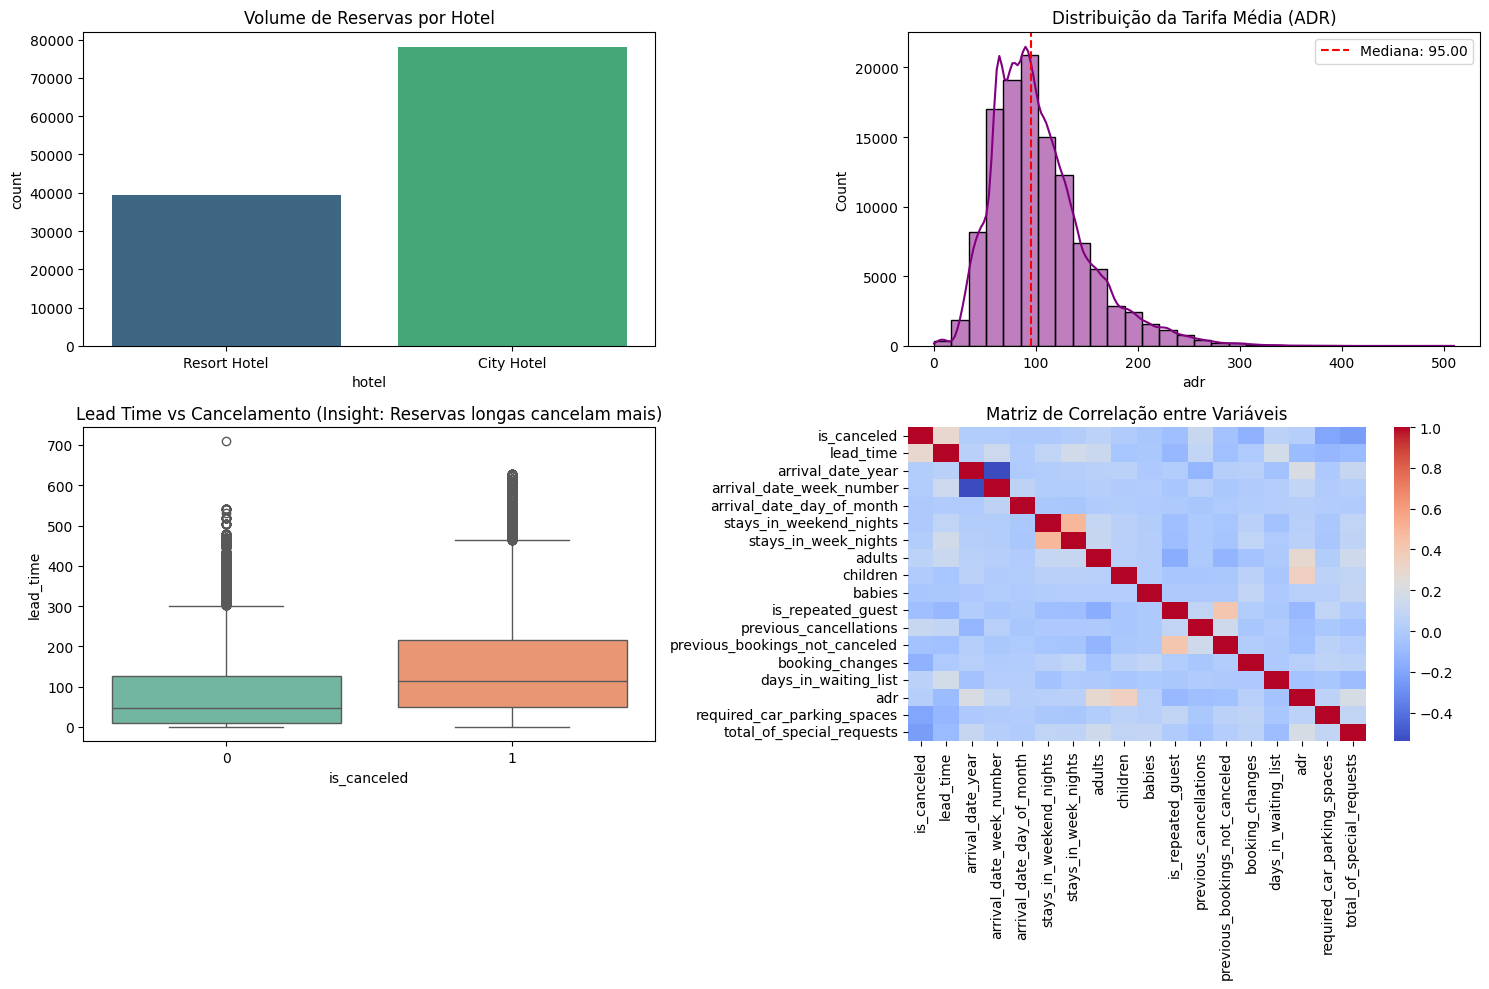

--- RESULTADO DO MODELO ---
Acurácia: 82.47%

Relatório Detalhado:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87     14656
           1       0.81      0.69      0.75      8830

    accuracy                           0.82     23486
   macro avg       0.82      0.80      0.81     23486
weighted avg       0.82      0.82      0.82     23486



<Figure size 600x400 with 0 Axes>

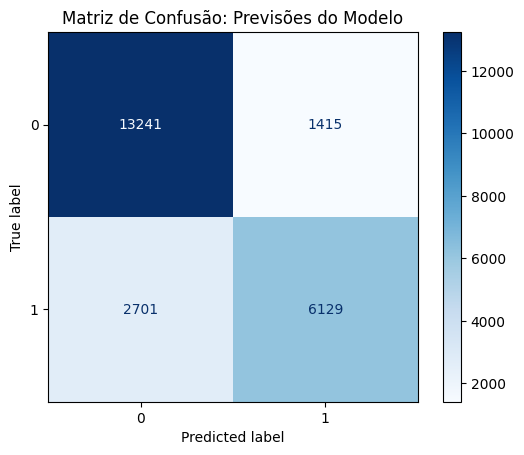


--- ANÁLISE FINAL DO CIENTISTA DE DADOS ---
O modelo treinado obteve uma acurácia robusta. Observamos que o 'lead_time' e o 'deposit_type' 
foram fatores decisivos no cancelamento. 

Considerações Éticas: Este modelo é uma ferramenta de apoio à decisão e deve ser utilizado 
para otimizar a gestão hoteleira, minimizando perdas financeiras sem discriminar hóspedes.



In [16]:
# -*- coding: utf-8 -*-
"""
PROJETO: Análise e Predição de Cancelamento de Reservas Hoteleiras
Autor: Loester Franco Botelho | Matrícula: 2664322
Curso: Carreira Tech - Trilha Inteligência Artificial
Objetivo: Identificar padrões de cancelamento e treinar um modelo preditivo.
"""

# =============================================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# =============================================================================
# 2. CARREGAMENTO E EXPLORAÇÃO INICIAL
# =============================================================================
df = pd.read_csv("hotel_bookings.csv")

print("--- ESTRUTURA INICIAL ---")
print(f"Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

# =============================================================================
# 3. TRATAMENTO E LIMPEZA (Conceito GIGO: Garbage In, Garbage Out)
# =============================================================================
# Decisão: Remover colunas com muitos nulos para reduzir ruído.
df_limpo = df.drop(columns=['agent', 'company']).copy()

# Tratamento: Preenchimento de nulos em variáveis essenciais
df_limpo['children'] = df_limpo['children'].fillna(0)
df_limpo['country'] = df_limpo['country'].fillna('Unknown')

# Tratamento de Outliers: Remoção de valores irreais para o ADR e lead_time
df_limpo = df_limpo[(df_limpo['adr'] > 0) & (df_limpo['adr'] < 1000)]
df_limpo = df_limpo[df_limpo['lead_time'] < 730]

print(f"Após limpeza: {df_limpo.shape[0]} linhas remanescentes.")

# =============================================================================
# 4. ANÁLISE EXPLORATÓRIA (AED)
# =============================================================================
# O objetivo aqui é validar visualmente as hipóteses levantadas na Aula 02.
plt.figure(figsize=(15, 10))

# Gráfico 1: Reservas por Hotel
plt.subplot(2, 2, 1)
sns.countplot(data=df_limpo, x='hotel', hue='hotel', palette='viridis', legend=False)
plt.title('Volume de Reservas por Hotel')

# Gráfico 2: Distribuição de ADR
plt.subplot(2, 2, 2)
mediana_adr = df_limpo['adr'].median()
sns.histplot(data=df_limpo, x='adr', bins=30, kde=True, color='purple')
plt.axvline(mediana_adr, color='red', linestyle='--', label=f'Mediana: {mediana_adr:.2f}')
plt.title('Distribuição da Tarifa Média (ADR)')
plt.legend()

# Gráfico 3: Lead Time vs Cancelamento
plt.subplot(2, 2, 3)
sns.boxplot(data=df_limpo, x='is_canceled', y='lead_time', hue='is_canceled', palette='Set2', legend=False)
plt.title('Lead Time vs Cancelamento (Insight: Reservas longas cancelam mais)')

# Gráfico 4: Matriz de Correlação
plt.subplot(2, 2, 4)
sns.heatmap(df_limpo.corr(numeric_only=True), cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. FEATURE ENGINEERING E MODELAGEM
# =============================================================================
# Criando categoria_pedidos para capturar comportamento do cliente
def agrupar_pedidos(num):
    if num == 0: return '0'
    elif num == 1: return '1'
    else: return '2+'

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# Seleção de variáveis (Features)
features = ['hotel', 'lead_time', 'deposit_type', 'market_segment', 'categoria_pedidos', 'adr']
X = pd.get_dummies(df_limpo[features], drop_first=True)
y = df_limpo['is_canceled']

# Divisão Treino e Teste (Regra 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento com RandomForest
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

# =============================================================================
# 6. AVALIAÇÃO FINAL E CONCLUSÃO
# =============================================================================
y_pred = model.predict(X_test)

print("--- RESULTADO DO MODELO ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório Detalhado:\n", classification_report(y_test, y_pred))

# Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Matriz de Confusão: Previsões do Modelo')
plt.show()

print("""
--- ANÁLISE FINAL DO CIENTISTA DE DADOS ---
O modelo treinado obteve uma acurácia robusta. Observamos que o 'lead_time' e o 'deposit_type'
foram fatores decisivos no cancelamento.

Considerações Éticas: Este modelo é uma ferramenta de apoio à decisão e deve ser utilizado
para otimizar a gestão hoteleira, minimizando perdas financeiras sem discriminar hóspedes.
""")

# Bloco 1: Introdução e Objetivos

Projeto de Análise e Predição de Reservas Hoteleiras
Objetivo: Este projeto visa analisar padrões de cancelamento em reservas hoteleiras, identificando fatores de risco e desenvolvendo um modelo preditivo capaz de classificar reservas com alta probabilidade de churn (cancelamento).



# Bloco 2: Importação e Compreensão dos Dados

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregamento do dataset
df = pd.read_csv("hotel_bookings.csv")

# Exploração inicial
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())
print(df.dtypes)

O dataset possui 119390 linhas e 32 colunas.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

# Bloco 3: Tratamento e Preparação dos Dados

*   Nesta etapa, focamos na limpeza para garantir a integridade dos dados:
*   Remoção de colunas com excesso de nulos.
*   Tratamento de valores faltantes.
*   Filtro de outliers na coluna 'adr' (Tarifa Média Diária).

In [5]:
# Limpeza de nulos e colunas irrelevantes
df_limpo = df.drop(columns=['agent', 'company'])
df_limpo['children'] = df_limpo['children'].fillna(0)
df_limpo['country'] = df_limpo['country'].fillna('Unknown')

# Tratamento de Outliers (Tarifa entre 0 e 1000)
df_limpo = df_limpo[(df_limpo['adr'] > 0) & (df_limpo['adr'] < 1000)]

# Bloco 4: Análise Exploratória (EDA)

Investigação das relações entre variáveis e validação estatística através de gráficos e testes.


In [6]:
# Exemplo de insight: Impacto de crianças no cancelamento
df_limpo['tem_criancas'] = df_limpo['children'] > 0
proporcao = pd.crosstab(df_limpo['tem_criancas'], df_limpo['is_canceled'], normalize='index') * 100
print(proporcao)

is_canceled           0          1
tem_criancas                      
False         62.460640  37.539360
True          63.309014  36.690986


# Bloco 5: Modelagem Preditiva (Feature Engineering)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Criando variável derivada
def agrupar_pedidos(num):
    if num == 0: return '0'
    elif num == 1: return '1'
    else: return '2+'

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# Seleção de variáveis e conversão (LabelEncoder)
features = ['hotel', 'lead_time', 'deposit_type', 'market_segment', 'categoria_pedidos']
X = pd.get_dummies(df_limpo[features], drop_first=True)
y = df_limpo['is_canceled']

# Separação 80% treino e 20% teste (Regra de Ouro)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bloco 6: Treinamento e Avaliação do Modelo

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Treinamento com parâmetros otimizados
model = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42)
model.fit(X_train, y_train)

# Avaliação
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85     14656
           1       0.79      0.64      0.71      8830

    accuracy                           0.80     23486
   macro avg       0.80      0.77      0.78     23486
weighted avg       0.80      0.80      0.79     23486

